[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Adaptive Methods: AdaGrad, RMSProp and Adam

Every method so far has kept one thing fixed: a single global learning rate, applied identically to every parameter in the network.

This notebook is about problems where that assumption is an issue, 
and about the methods that drop it by keeping a **separate step size for every parameter**.  
Adam is the one we have already been using for training transformer models.
In this notebook we will establish why, and why it was not used for training convolutional networks.
We will not only show that Adam wins for language modeling, but also find the property of the data that
leads to that.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import math
import re
import time
from collections import Counter

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu')
print(f'Using {device} device')
torch.manual_seed(0)

Using mps device


## Some parameters are updated far less often than others

As in previous notebooks we will use the **TinyStories** corpus — short synthetic children's stories.
We take the first two million characters, which is enough to make the point and small enough to train
on in a few of minutes.

The choice of size deliberate:
Two million characters gives roughly 445,000 tokens against
a training budget of about 615,000 token-predictions, so the model sees the
corpus a little over once.  That matters: a model trained for twenty epochs on
a tiny corpus is memorizing, and comparisons between optimizers then start to
measure how fast each one memorizes rather than how fast it learns.

In [2]:
CORPUS = '../data/tinystories.txt'
N_CHARS = 2_000_000

def load_words(path, cap=None, n_chars=N_CHARS, min_count=2):
    """Word-level tokenization, optionally capping the vocabulary size.

    Words outside the cap (or below `min_count`) become <unk>, which truncates
    the tail of the distribution rather than reweighting it."""
    text = open(path, encoding='utf-8').read()[:n_chars].lower()
    words = re.findall(r"[a-z']+|[.,!?;]", text)
    counts = Counter(words)
    kept = [w for w, c in counts.most_common() if c >= min_count]
    if cap is not None:
        kept = kept[:cap - 1]                      # leave room for <unk>
    vocab = ['<unk>'] + kept
    stoi = {w: i for i, w in enumerate(vocab)}
    ids = torch.tensor([stoi.get(w, 0) for w in words], dtype=torch.long)
    return ids, vocab

ids, vocab = load_words(CORPUS)
common = Counter(ids.tolist()).most_common(6)
print(f'{len(ids):,} tokens, {len(vocab):,} unique vocabulary entries')
print(f'a uniform guess would cost ln({len(vocab)}) = {math.log(len(vocab)):.2f} nats')
print('most common:', [(vocab[i], c) for i, c in common])

444,903 tokens, 4,648 unique vocabulary entries
a uniform guess would cost ln(4648) = 8.44 nats
most common: [('.', 36597), ('the', 22177), ('and', 18156), (',', 17625), ('to', 12810), ('a', 11744)]


Word frequencies follow a **Zipf** distribution: rank a word type by
frequency and its count falls off as a power law of the rank, showing as a
straight line on log-log axes.  
As a result, the commonest words appear thousands of times in a pass over the corpus; most of the vocabulary appears once or twice.

word level             V =  4,648   Zipf slope  -1.51   top-10 share  34.5%


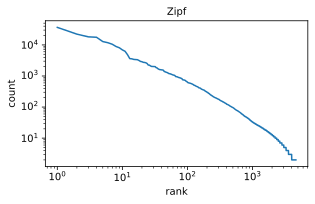

In [3]:
def unigram_counts(ids):
    return np.array(sorted(Counter(ids.tolist()).values(), reverse=True))

def zipf_summary(ids, vocab, label):
    """Fitted Zipf slope and how concentrated the distribution is."""
    counts = unigram_counts(ids)
    p = counts / counts.sum()
    rank = np.arange(1, len(counts) + 1)
    slope = np.polyfit(np.log(rank), np.log(counts), 1)[0]
    print(f'{label:22s} V = {len(vocab):6,d}   Zipf slope {slope:6.2f}   '
          f'top-10 share {100 * p[:10].sum():5.1f}%')

zipf_summary(ids, vocab, 'word level')

counts = unigram_counts(ids)
plt.figure(figsize=(4.5, 3))
plt.loglog(np.arange(1, len(counts) + 1), counts)
plt.xlabel('rank'); plt.ylabel('count'); plt.title('Zipf', fontsize=10)
plt.tight_layout()

Now let's connect that to the model's parameters.  A word has parameters associated with it in two places, and how often either is updated is set by how often the word appears.

The **output layer** holds one row per vocabulary entry — a $d \times V$ matrix
mapping the final hidden state to a score for every word.  A word's row
receives a gradient from the positions where that word is the target, plus a
much weaker signal from being a competitor in the softmax elsewhere.

The **embedding layer** holds one row per entry as well, applied only at positions
where the word appears and updated only then.  A word occurring
three times in the corpus gets three chances to have its representation shaped,
against tens of thousands for common words like *the*.  As a result, its row stays near its random
initialization: the model's picture of rare words is barely learned at
all.

The two are separate matrices in general.  Many small language models tie them,
this one included — `head.weight` *is* `emb.weight`, and
`05_llm/module05_03_training_a_gpt.ipynb` explains the reasoning. So here a
single row per word plays both parts and collects both kinds of gradient.

So the frequency distribution above is, the distribution of *how
often each of those rows gets an update*.  Let's count how many rows see a
target in a single batch.

In [4]:
CONTEXT = 32
BATCH = 32

def batches(ids, n_batches, batch_size=BATCH, context=CONTEXT, seed=0):
    """Random (input, next-token) windows of length `context`."""
    generator = torch.Generator().manual_seed(seed)
    top = len(ids) - context - 1
    for _ in range(n_batches):
        start = torch.randint(0, top, (batch_size,), generator=generator)
        x = torch.stack([ids[k:k + context] for k in start])
        y = torch.stack([ids[k + 1:k + context + 1] for k in start])
        yield x, y

def rows_updated(ids, vocab, n=20):
    return float(np.mean([len(torch.unique(y)) / len(vocab)
                          for _, y in batches(ids, n)]))

fraction = rows_updated(ids, vocab)
print(f'{BATCH} x {CONTEXT} = {BATCH * CONTEXT} target tokens per batch')
print(f'distinct vocabulary items among them: {fraction * len(vocab):.0f} of {len(vocab):,}')
print(f'so {100 * fraction:.1f}% of output rows get a gradient in a given step '
      f'— the other {100 * (1 - fraction):.1f}% get none')

32 x 32 = 1024 target tokens per batch
distinct vocabulary items among them: 366 of 4,648
so 7.9% of output rows get a gradient in a given step — the other 92.1% get none


Fewer than one row in twelve is touched per step.  A rare word appearing three
times in the corpus contributes to perhaps three of the six hundred updates in
a training run — and when it does, its gradient is *large*, because the model
has had almost no opportunity to fit it.

Now consider what a single global learning rate has to do here.  It must be
small enough not to destabilize the row for common words like *the*, which consistently receive
a gradient update at every single step, and large enough to make progress on
the row for a word that will contribute three gradients in total.  There is no
value that does both.  Momentum does not help: averaging gradients over time
changes the direction, but the row for a rare word has no history to average —
it is zero almost always.

This is the situation adaptive methods are for.

## AdaGrad

The idea is to give each parameter its own step size, scaled down in
proportion to how much gradient that parameter has already received.  AdaGrad
accumulates the sum of squared gradients per coordinate,

$$\mathbf{s}_t = \mathbf{s}_{t-1} + \mathbf{g}_t^2,
\qquad
\mathbf{x}_t = \mathbf{x}_{t-1} -
  \frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t,$$

where everything is elementwise and $\epsilon \approx 10^{-8}$ prevents a
division by zero.

Read the second equation as a per-parameter learning rate
$\eta / \sqrt{s_{t,i}}$.  A coordinate that has seen large or frequent
gradients has a large $s_i$ and takes small steps; a coordinate that has been
mostly idle has a small $s_i$ and takes large ones.  For the output layer of a
language model this is exactly the correction we just argued for, and it is
obtained without knowing anything about words or frequencies — it falls out of
the gradient history itself.

It is also, in a rough sense, curvature information.  For a least-squares
problem, $\mathbb{E}[g_i^2]$ relates to the $i$-th diagonal entry of the
Hessian, so dividing by $\sqrt{s_i}$ approximates a diagonal preconditioner —
a cheap, $\mathcal{O}(d)$ shadow of the $\mathcal{O}(d^3)$ Newton step we
rejected in notebook 1.  It cannot fix rotated ill-conditioning, for the same
reason standardization could not; it is still a diagonal correction.

**AdaGrad's defect is that its accumulator grows without bound.**  $\mathbf{s}_t$
is a sum over every step taken so far and never decreases, so every
per-parameter learning rate decays monotonically towards zero, whatever the
loss is doing.  On a convex problem that is a feature — it supplies the
decaying schedule the theory asks for.  On a deep network, where you may want
to still be learning after a hundred thousand steps, it means training grinds
to a halt while the loss is still falling.

## RMSProp

RMSProp fixes the issue: if the trouble is that $\mathbf{s}_t$
remembers every gradient the parameter has ever received, give it a shorter
memory.  It replaces the running sum with a running *average*:

$$\mathbf{s}_t = \gamma \mathbf{s}_{t-1} + (1 - \gamma)\mathbf{g}_t^2,
\qquad
\mathbf{x}_t = \mathbf{x}_{t-1} -
  \frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t,$$

with $\gamma$ typically $0.9$.  This is the same leaky average that momentum
applied to the gradient, applied instead to the *squared* gradient — a window
over roughly the last $1/(1 - \gamma)$ steps rather than over all of history.
The per-parameter rates now track recent gradient magnitude and can go back up
if a parameter becomes active again.  Nothing decays to zero by construction.

RMSProp was proposed by Geoffrey Hinton in a Coursera lecture and, famously,
never published as a paper; it is cited to the lecture slides.

Run both on the same pair of parameters — one receiving a gradient at every
step, one at a step in twenty — and watch the per-parameter learning rates.

AdaGrad  frequent: 0.1000 at step 1 -> 0.0054 averaged over the last 100 steps
         rare is 4.7x the frequent rate
RMSProp  frequent: 0.3162 at step 1 -> 0.1000 averaged over the last 100 steps
         rare is 5.9x the frequent rate


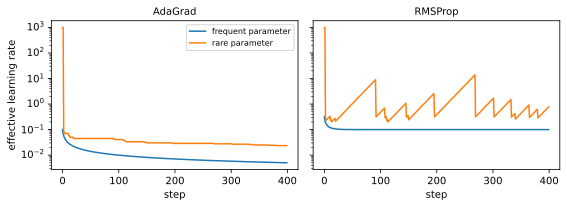

In [5]:
steps = 400
g_frequent = 1.0                             # a gradient at every step
rng = np.random.default_rng(0)
g_rare = (rng.random(steps) < 0.05) * 1.0    # the same gradient, 5% as often

def adagrad_rate(grads, eta=0.1, eps=1e-8):
    s, rates = 0.0, []
    for g in grads:
        s += g ** 2
        rates.append(eta / math.sqrt(s + eps))
    return rates

def rmsprop_rate(grads, eta=0.1, gamma=0.9, eps=1e-8):
    s, rates = 0.0, []
    for g in grads:
        s = gamma * s + (1 - gamma) * g ** 2
        rates.append(eta / math.sqrt(s + eps))
    return rates

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for ax, rate_fn, name in [(axes[0], adagrad_rate, 'AdaGrad'),
                          (axes[1], rmsprop_rate, 'RMSProp')]:
    ax.plot(rate_fn([g_frequent] * steps), label='frequent parameter')
    ax.plot(rate_fn(g_rare), label='rare parameter')
    ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_title(name, fontsize=10)
axes[0].set_ylabel('effective learning rate'); axes[0].legend(fontsize=8)
plt.tight_layout()

for name, rate_fn in [('AdaGrad', adagrad_rate), ('RMSProp', rmsprop_rate)]:
    frequent = rate_fn([g_frequent] * steps)
    rare = rate_fn(g_rare)
    print(f'{name:8s} frequent: {frequent[0]:.4f} at step 1 -> '
          f'{np.mean(frequent[-100:]):.4f} averaged over the last 100 steps')
    print(f'{"":8s} rare is {np.mean(rare[-100:]) / np.mean(frequent[-100:]):.1f}x '
          f'the frequent rate')

Both methods do the thing we asked for: the rare parameter ends up with a step
size several times larger than the frequent one — about $4.7\times$ under
AdaGrad and about $5.9\times$ under RMSProp — with no knowledge of which
parameter is which.

The difference between the panels is that the AdaGrad 
curves decrease without limit: after 400 steps the frequent parameter's
rate has fallen twentyfold, and it will keep falling as $1/\sqrt{t}$ forever.  
On the right both settle at a level set by the
*recent* gradient magnitude and stay there.  (The rare curve on the right is
visibly spiky, because a leaky average over ~10 steps is a small sample when
the gradient arrives one step in twenty.)

While RMSProp ixes the per-parameter *scale*, it does not have momentum, which the previous notebook showed was worth having.   The obvious thing to do is both.

## Adam

**Adam** — adaptive moment estimation — keeps the leaky average of the gradient
*and* the leaky average of the squared gradient:

$$\mathbf{v}_t = \beta_1 \mathbf{v}_{t-1} + (1 - \beta_1)\mathbf{g}_t,
\qquad
\mathbf{s}_t = \beta_2 \mathbf{s}_{t-1} + (1 - \beta_2)\mathbf{g}_t^2,$$

with defaults $\beta_1 = 0.9$ and $\beta_2 = 0.999$.  The first is momentum
(written as a proper average, so it does not carry momentum's $1/(1-\beta)$
scale-up); the second is RMSProp.

There is one wrinkle.  Both accumulators start at zero, which biases them
towards zero for as long as the initialization has not washed out.  After $t$
steps the weights in $\mathbf{v}_t$ sum to $1 - \beta_1^t$ rather than to 1.
Adam divides it out:

$$\hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_1^t},
\qquad
\hat{\mathbf{s}}_t = \frac{\mathbf{s}_t}{1 - \beta_2^t},
\qquad
\mathbf{x}_t = \mathbf{x}_{t-1} -
  \frac{\eta\,\hat{\mathbf{v}}_t}{\sqrt{\hat{\mathbf{s}}_t} + \epsilon}.$$

This is **bias correction**, and with $\beta_2 = 0.999$ it is not a
technicality: the second-moment accumulator is an average over about a thousand
steps, so it takes a thousand steps to warm up on its own.  Without the
correction, $\sqrt{\hat{\mathbf{s}}}$ is far too small early on and the first
steps are enormous.

beta = 0.9: accumulator is within 5% of its true scale after 29 steps
beta = 0.999: accumulator is within 5% of its true scale after 2995 steps


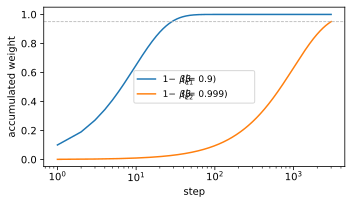

In [6]:
t = np.arange(1, 3001)
plt.figure(figsize=(5, 3))
for beta, label in [(0.9, r'$1-\beta_1^t$  ($\beta_1$ = 0.9)'),
                    (0.999, r'$1-\beta_2^t$  ($\beta_2$ = 0.999)')]:
    plt.plot(t, 1 - beta ** t, label=label)
plt.axhline(0.95, color='0.7', lw=0.8, ls='--')
plt.xscale('log'); plt.xlabel('step'); plt.ylabel('accumulated weight')
plt.legend(fontsize=9); plt.tight_layout()

for beta in (0.9, 0.999):
    reach = int(np.argmax(1 - beta ** t > 0.95)) + 1
    print(f'beta = {beta}: accumulator is within 5% of its true scale '
          f'after {reach} steps')

The momentum accumulator is warmed up within about thirty steps; the
second-moment accumulator needs about three thousand.  Bias correction is what
makes the first three thousand steps usable.  It is also the reason Adam still
often wants a warmup schedule on top, which is the subject of the next
notebook.

A useful way to read the final update: the numerator is a smoothed gradient and
the denominator is (roughly) the standard deviation of that same gradient, so
the ratio is close to a *sign*, bounded by about $\eta$ in magnitude.  Adam's
step size is therefore roughly $\eta$ per parameter almost regardless of how
large the gradient is, which is why Adam's default learning rate ($10^{-3}$) is
so much smaller than SGD's and so much more portable between problems.

Here it is written out, to be checked against PyTorch's.

In [7]:
def adam_step(params, state, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
    """One Adam update, in place.  `state` holds (t, v, s)."""
    beta1, beta2 = betas
    state['t'] += 1
    t = state['t']
    with torch.no_grad():
        for i, p in enumerate(params):
            g = p.grad
            state['v'][i] = beta1 * state['v'][i] + (1 - beta1) * g
            state['s'][i] = beta2 * state['s'][i] + (1 - beta2) * g ** 2
            v_hat = state['v'][i] / (1 - beta1 ** t)      # bias correction
            s_hat = state['s'][i] / (1 - beta2 ** t)
            p -= lr * v_hat / (s_hat.sqrt() + eps)
            p.grad = None


# check it against torch.optim.Adam on a small quadratic
torch.manual_seed(0)
target = torch.randn(50)
mine = torch.zeros(50, requires_grad=True)
theirs = torch.zeros(50, requires_grad=True)
state = {'t': 0, 'v': [torch.zeros(50)], 's': [torch.zeros(50)]}
reference = torch.optim.Adam([theirs], lr=1e-2)

for _ in range(100):
    ((mine - target) ** 2).sum().backward()
    adam_step([mine], state, lr=1e-2)
    reference.zero_grad()
    ((theirs - target) ** 2).sum().backward()
    reference.step()

print(f'largest disagreement after 100 steps: '
      f'{(mine - theirs).abs().max().item():.2e}')

largest disagreement after 100 steps: 3.58e-07


## Comparison on training a language model

In the following we demonstrate that our argument on rare words rows being starved of gradient, and that a per-parameter step size should compensate for it translate to a performance advantage for the Adam optimizer over SGD and SGD with momentum.
In thsi expriment we train a small decoder-only transformer at a size that runs in about half a minute on the corpus above.

The model is deliberately compact; the fully explained version is in `05_llm/module05_03_training_a_gpt.ipynb`.  Note the tied embedding mentioned above:
`head.weight` *is* `emb.weight`, so the output rows are the input embeddings.

In [8]:
class Block(nn.Module):
    """Pre-norm decoder block: causal self-attention, then a position-wise FFN."""
    def __init__(self, d, heads, ffn):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attention = nn.MultiheadAttention(d, heads, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.GELU(), nn.Linear(ffn, d))

    def forward(self, X, mask):
        Z = self.ln1(X)
        attended, _ = self.attention(Z, Z, Z, attn_mask=mask, need_weights=False)
        X = X + attended
        return X + self.ffn(self.ln2(X))


class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d=128, heads=4, ffn=512, blocks=2,
                 context=CONTEXT):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d)
        self.pos = nn.Embedding(context, d)
        self.blocks = nn.ModuleList([Block(d, heads, ffn) for _ in range(blocks)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab_size, bias=False)
        self.head.weight = self.emb.weight                 # weight tying
        self.register_buffer('mask', torch.triu(
            torch.full((context, context), float('-inf')), diagonal=1))

    def forward(self, X):
        t = X.shape[1]
        Z = self.emb(X) + self.pos(torch.arange(t, device=X.device))
        for block in self.blocks:
            Z = block(Z, self.mask[:t, :t])
        return self.head(self.ln_f(Z))


reference_model = TinyGPT(len(vocab))
n_embedding = (reference_model.emb.weight.numel()
               + reference_model.pos.weight.numel())
n_total = sum(p.numel() for p in reference_model.parameters())
print(f'{n_total:,} parameters: {n_embedding:,} in the embedding '
      f'(tied to the output layer), {n_total - n_embedding:,} in the body')

995,840 parameters: 599,040 in the embedding (tied to the output layer), 396,800 in the body


In [9]:
STEPS = 600

def train_lm(ids, vocab, make_optimizer, steps=STEPS, seed=0, clip=1.0):
    """Train TinyGPT; return the per-step loss and the elapsed time."""
    torch.manual_seed(seed)
    model = TinyGPT(len(vocab)).to(device)
    optimizer = make_optimizer(model.parameters())
    losses = []
    start = time.time()
    for X, Y in batches(ids, steps):
        X, Y = X.to(device), Y.to(device)
        loss = F.cross_entropy(model(X).reshape(-1, len(vocab)), Y.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        losses.append(loss.item())
        if not math.isfinite(losses[-1]):
            break
    return losses, time.time() - start


def final_loss(losses, window=50):
    """Mean over the last `window` steps, to see past the batch-to-batch noise."""
    return float(np.mean(losses[-window:])) if math.isfinite(losses[-1]) else float('inf')

As in the last notebook, each method gets its own learning-rate sweep.  This
is essential here: Adam's usable range is two orders of magnitude below SGD's,
so any comparison at a shared learning rate is meaningless.

This cell is the expensive one — seven runs, roughly four minutes on a CPU and
well under one on a GPU.

In [10]:
SGD_GRID = [0.1, 0.3, 1.0]
ADAM_GRID = [0.003, 0.01]

SWEEPS = {
    'SGD':      (SGD_GRID, lambda p, lr: torch.optim.SGD(p, lr=lr)),
    'momentum': ([0.03, 0.1],
                 lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9)),
    'Adam':     (ADAM_GRID, lambda p, lr: torch.optim.Adam(p, lr=lr)),
}

def sweep(ids, vocab, sweeps=SWEEPS, quiet=False):
    """Best result per method over its own learning rate grid."""
    best = {}
    for name, (grid, make) in sweeps.items():
        for lr in grid:
            losses, elapsed = train_lm(ids, vocab, lambda p, lr=lr: make(p, lr))
            score = final_loss(losses)
            if not quiet:
                print(f'  {name:9s} lr {lr:<7g} loss {score:7.3f}   ({elapsed:.0f} s)')
            if name not in best or score < best[name][0]:
                best[name] = (score, lr, losses)
    return best

best_full = sweep(ids, vocab)

  SGD       lr 0.1     loss   6.932   (7 s)
  SGD       lr 0.3     loss   6.794   (7 s)
  SGD       lr 1       loss   6.798   (7 s)
  momentum  lr 0.03    loss   6.256   (7 s)
  momentum  lr 0.1     loss   5.787   (7 s)
  Adam      lr 0.003   loss   4.358   (8 s)
  Adam      lr 0.01    loss   4.820   (8 s)



method          lr     loss   perplexity
SGD            0.3    6.794        892.6
momentum       0.1    5.787        325.9
Adam         0.003    4.358         78.1
(uniform)             8.444       4648.0


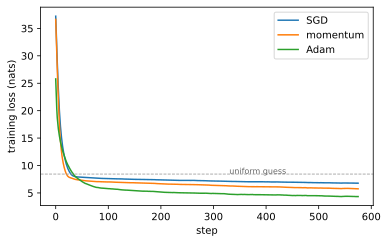

In [11]:
uniform = math.log(len(vocab))
print(f'\n{"method":10s} {"lr":>7s} {"loss":>8s} {"perplexity":>12s}')
for name, (score, lr, _) in best_full.items():
    print(f'{name:10s} {lr:7g} {score:8.3f} {math.exp(score):12.1f}')
print(f'{"(uniform)":10s} {"":7s} {uniform:8.3f} {len(vocab):12.1f}')

plt.figure(figsize=(5.5, 3.5))
for name, (_, _, losses) in best_full.items():
    plt.plot(np.convolve(losses, np.ones(25) / 25, mode='valid'), label=name)
plt.axhline(uniform, color='0.6', lw=0.8, ls='--')
plt.text(STEPS * 0.55, uniform + 0.05, 'uniform guess', fontsize=8, color='0.4')
plt.xlabel('step'); plt.ylabel('training loss (nats)')
plt.legend(); plt.tight_layout()

Each method at its own best learning rate, same architecture, same data, same 600
steps:

| method | loss | perplexity |
|---|---|---|
| SGD | 6.80 | 900 |
| SGD with momentum | 5.81 | 335 |
| Adam | 4.36 | 78 |

Recall that perplexity — $e^{\text{loss}}$, is the effective number of words the model is
choosing between.  A uniform guess over the vocabulary would score 4,648.  SGD gets that down to about 900.  Adam gets it to about 78, **eleven and a half times better than SGD** and more than four
times better than momentum.

Compare this with the previous notebook, where momentum bought a factor of six
over SGD and Adam was roughly tied with momentum.  Here the ranking is
different and the margin is much larger.

## Testing the explanation

The claim at the top of the notebook was that the advantage comes from the
heavy-tailed distribution of the output classes, which leaves most output rows
starved of gradient.

Let's put that claim to the test.  If the number of
starved classes is what matters, then **shrinking the vocabulary should shrink
the gap**.

The design has to change the number of classes and nothing else.  Capping the
vocabulary does that: the tokenizer stays exactly as it is, and every word
below the cap is mapped to `<unk>`, which truncates the tail of the
distribution rather than reweighting it.

In [12]:
CAPS = [50, 200, 1000, None]

curve = []
for cap in CAPS:
    ids_c, vocab_c = load_words(CORPUS, cap=cap)
    best = sweep(ids_c, vocab_c, quiet=True, sweeps={
        'SGD':  ([0.1, 0.3], SWEEPS['SGD'][1]),
        'Adam': ([0.003], SWEEPS['Adam'][1])})
    gap = best['SGD'][0] - best['Adam'][0]
    curve.append({'V': len(vocab_c), 'ids': ids_c, 'vocab': vocab_c, 'gap': gap})
    print(f'V = {len(vocab_c):5,d}   rows/batch {100 * rows_updated(ids_c, vocab_c):5.1f}%'
          f'   SGD {best["SGD"][0]:6.3f}   Adam {best["Adam"][0]:6.3f}   '
          f'gap {gap:5.3f} nats ({math.exp(gap):5.1f}x)')

V =    50   rows/batch  98.2%   SGD  2.824   Adam  1.897   gap 0.928 nats (  2.5x)
V =   200   rows/batch  75.9%   SGD  4.018   Adam  2.729   gap 1.289 nats (  3.6x)
V = 1,000   rows/batch  29.4%   SGD  5.523   Adam  3.774   gap 1.749 nats (  5.7x)
V = 4,648   rows/batch   7.9%   SGD  6.794   Adam  4.358   gap 2.436 nats ( 11.4x)


Monotone, across a factor of nearly one hundred in vocabulary size, with the
tokenization held fixed.  The gap grows from about $0.95$ nats at
$V = 50$ to about $2.44$ at the full vocabulary.  The fraction of output rows updated per batch
falls the other way, from 98% to 8%.

### Effective vocabulary

To plot the gap against "how many classes there are" we have to say what
counts as a class.  The obvious choice is $V$, and it is not quite
satisfactory, because $V$ counts vocabulary items that contribute almost nothing.  Setting
`min_count=1` instead of 2 would add every word that occurs exactly once,
raising $V$ by about a third while changing what the model actually experiences
hardly at all.  A count that can be inflated by things the model almost never
sees is a shaky $x$-axis.

The standard repair is to ask how many classes there would be *if they were
equally common*, and you have already built that quantity.  The perplexity
notebook of the language-modelling module showed that a distribution with
entropy $H$ is as uncertain, on average, as a uniform choice among $e^{H}$
options — the loaded die with six faces on paper and about $1.3$ in practice.
Applied to a corpus's unigram distribution, $e^{H}$ is exactly **the perplexity
of a unigram language model**, the weakest baseline that notebook builds. Here
we are using it to describe the data rather than to score a model, and in that
role it is usually called the **effective vocabulary**.

Compute it for all four corpora and plot the gap against each count.

In [13]:
def effective_vocabulary(ids):
    """exp of the unigram entropy: the perplexity of a unigram model."""
    p = unigram_counts(ids) / len(ids)
    return math.exp(float(-(p * np.log(p)).sum()))


for point in curve:
    point['effective'] = effective_vocabulary(point['ids'])

print(f'{"V":>8s}{"effective V":>14s}')
for point in curve:
    print(f'{point["V"]:8,d}{point["effective"]:14.1f}')

       V   effective V
      50          12.5
     200          45.4
   1,000         162.6
   4,648         303.5


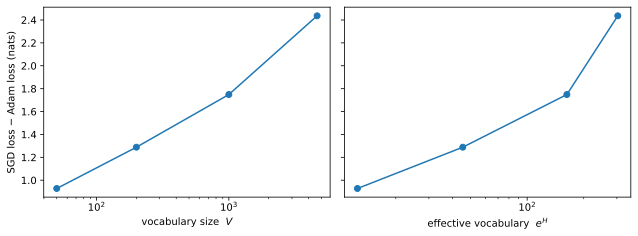

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)

for ax, key, name in [(axes[0], 'V', 'vocabulary size  $V$'),
                      (axes[1], 'effective', 'effective vocabulary  $e^H$')]:
    ax.plot([p[key] for p in curve], [p['gap'] for p in curve], '-o')
    ax.set_xscale('log'); ax.set_xlabel(name)
axes[0].set_ylabel('SGD loss $-$ Adam loss (nats)')
plt.tight_layout()

The two panels are the same shape, which is exactly what we should expect:
capping the vocabulary removes rare types, and that lowers both counts
together.  Nothing here can separate them, so the choice between the axes is
made on other grounds — $e^H$ is the one that cannot be inflated by types the
model almost never sees, and it is the one to reach for when the two are pulled
apart, which is what the next section does.

This experiment is a miniature of a result in the literature.  Adam's advantage
on language models was for years attributed to gradient *noise*; Kunstner et
al. (2023) showed that the gap persists in the full-batch setting where there
is no noise at all, and traced it instead to the heavy-tailed class
distribution — running the same argument we just ran, at scale.

> Kunstner, F., Chen, J., Lavington, J. W., & Schmidt, M. (2023). Noise is not
> the main factor behind the gap between SGD and Adam on transformers, but sign
> descent might be. *International Conference on Learning Representations*.

Four points are suggestive rather than conclusive, so it is worth being precise
about what they show.  Capping moves $V$ and $e^H$ together, so this experiment
cannot say which of the two — if either — is the operative variable.  A control
that pulls them apart, flattening the distribution while leaving every word in
the vocabulary, moves the gap the *opposite* way from what a law in $e^H$ would
predict: what Adam is compensating for is the **spread** of update rates across
output rows, and vocabulary size is a good proxy for that spread here rather
than the mechanism behind it.  Exercise 3 runs the control.

So the claim is narrower than "the gap is a function of $e^H$".  It is that
**within a family of corpora differing only in how much of the Zipf tail they
retain, the gap grows smoothly and substantially with the amount retained** —
enough to rule out the explanations this notebook set out to test, and not
enough to write down a law.

## Which parameters actually need Adam?

The curve does not go to zero.  Even at $V = 50$, where essentially every
output row is updated at every step, Adam is still about $0.95$ nats ahead.  So
the output layer cannot be the whole story.

There is a direct way to find out how much of it the output layer is.  Split
the model in two — the tied embedding/output matrix on one side, the whole
transformer body on the other — and give Adam to one group and plain SGD to the
other.  PyTorch is happy to run two optimizers over disjoint parameter sets.

In [15]:
def train_split(ids, vocab, adam_on, lr_adam=3e-3, lr_sgd=0.1, seed=0):
    """Train with Adam on one parameter group and plain SGD on the other."""
    torch.manual_seed(seed)
    model = TinyGPT(len(vocab)).to(device)

    is_embedding = {'emb.weight', 'pos.weight'}    # head.weight *is* emb.weight
    embedding, body = [], []
    for name, p in model.named_parameters():
        (embedding if name in is_embedding else body).append(p)

    adam = lambda p: torch.optim.Adam(p, lr=lr_adam)
    sgd = lambda p: torch.optim.SGD(p, lr=lr_sgd)
    optimizers = {
        'nothing':    [sgd(embedding + body)],
        'embedding':  [adam(embedding), sgd(body)],
        'body':       [sgd(embedding), adam(body)],
        'everything': [adam(embedding + body)],
    }[adam_on]

    losses = []
    for X, Y in batches(ids, STEPS):
        X, Y = X.to(device), Y.to(device)
        loss = F.cross_entropy(model(X).reshape(-1, len(vocab)), Y.reshape(-1))
        for optimizer in optimizers:
            optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        for optimizer in optimizers:
            optimizer.step()
        losses.append(loss.item())
        if not math.isfinite(losses[-1]):
            break
    return final_loss(losses)


split = {}
for adam_on in ['nothing', 'embedding', 'body', 'everything']:
    split[adam_on] = train_split(ids, vocab, adam_on)
    print(f'Adam on {adam_on:11s} loss {split[adam_on]:6.3f}')

span = split['nothing'] - split['everything']
print()
for adam_on in ['embedding', 'body']:
    print(f'Adam on {adam_on:11s} closes '
          f'{100 * (split["nothing"] - split[adam_on]) / span:4.0f}% of the gap')

Adam on nothing     loss  6.932
Adam on embedding   loss  5.620
Adam on body        loss  5.543
Adam on everything  loss  4.358

Adam on embedding   closes   51% of the gap
Adam on body        closes   54% of the gap


**Roughly half each, and roughly additive.**  Adam on the embedding and output
matrix alone — with plain SGD running the entire transformer — recovers about
48% of the gap; Adam on the body alone, with SGD on the embedding, recovers
about 52%.

So the output layer is a large share of Adam's advantage here, but not most of
it.  The rest comes from the body, where the LayerNorm scales, the attention
projections and the two FFN matrices sit at quite different gradient scales and
benefit from a diagonal preconditioner for ordinary reasons that have nothing
to do with Zipf.

That also explains the floor in the curve above.  The body's contribution is
roughly constant at around $1.3$ nats whatever the vocabulary; the output
layer's contribution grows with the number of starved rows.  At $V = 50$ the
second term has nearly vanished, and what is left — about $0.95$ nats — is the
first.  Two independent experiments, one number.

One caveat, since this module has been careful about such things elsewhere: the
mixed runs reuse learning rates tuned for the *pure* settings rather than swept
for the mixture.  Read the 48/52 split as "roughly half each", not to two
significant figures.

## When not to reach for Adam

It would be a poor lesson to leave you with "Adam wins".  Three qualifications,
in increasing order of importance.

**On well-conditioned problems nothing wins.**  The $\kappa = 100$ regression
in the last notebook gave every method the same answer.  Most of the effort
spent choosing optimizers would be better spent on the data.

**Adam is not a preconditioner for correlated curvature.**  Its correction is
diagonal — one number per parameter — so it is subject to the same limit as
feature standardization: it can fix scale differences between coordinates and
cannot fix ill-conditioning that lies along combinations of them.

**On image classification, SGD with momentum remains competitive and often
generalizes better.**  This is the significant one.  The convolutional networks
of modules 06 and 07 were trained with plain `SGD` and that was not an
oversight: the standard recipes for ResNet and its descendants use SGD with
momentum, a large learning rate and a decay schedule, and they reach a *better
test accuracy* than Adam does, even where Adam reaches a lower training loss
faster.  The gap is in generalization, not optimization, and it is the sharpest
available reminder that these are two different things — the point this module
opened with.

Notice also where a vision model sits on the curve we just plotted.  A ten-way
image classifier has a vocabulary of ten, and because the classes are roughly
balanced its effective vocabulary is also about ten — off the left-hand end,
below even the $V = 50$ point.  The curve predicts almost no output-layer
benefit, which is exactly what is found.

A serviceable rule: **transformers and anything with a large softmax get Adam
(or AdamW); convolutional vision models get SGD with momentum and a schedule.**
That is a summary of what has been found to work, not a theorem.

## AdamW

One variant is worth knowing because it is what you will actually see in
transformer code.

Weight decay is meant to be an $L_2$ penalty $\frac{\lambda}{2}\|\mathbf{w}\|^2$
on the objective.  Implemented that way, it adds $\lambda\mathbf{w}$ to the
gradient — and Adam then divides that term by $\sqrt{\hat{s}}$ along with
everything else.  The amount of decay a parameter receives therefore depends on
its gradient history, which is not what anyone intended: parameters with small
gradients get decayed hard, parameters with large gradients barely at all.

**AdamW** *decouples* it, applying the decay directly to the parameter and
leaving the adaptive machinery alone:

$$\mathbf{x}_t = \mathbf{x}_{t-1}
  - \frac{\eta\,\hat{\mathbf{v}}_t}{\sqrt{\hat{\mathbf{s}}_t} + \epsilon}
  - \eta\lambda\,\mathbf{x}_{t-1}.$$

In PyTorch, `torch.optim.Adam(..., weight_decay=λ)` is the coupled version and
`torch.optim.AdamW(..., weight_decay=λ)` is the decoupled one.  For transformer
training AdamW is the default choice, usually with $\lambda$ around $0.1$ and
with biases and normalization parameters excluded from decay altogether.

> Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization.
> *International Conference on Learning Representations*.

## Summary

* AdaGrad divides each parameter's learning rate by the square root of its
  accumulated squared gradient.  Rarely-updated parameters get larger steps.
  Because the accumulator only grows, all learning rates decay to zero.
* RMSProp replaces the sum with a leaky average over the recent past, so rates
  track current gradient magnitude instead of total history.
* Adam is RMSProp plus momentum, plus bias correction for the fact that both
  accumulators start at zero.  With $\beta_2 = 0.999$ the second moment takes
  about 3,000 steps to warm up on its own, so the correction matters.
* On a word-level language model with a 4,648-type vocabulary — where under
  $8\%$ of output rows are updated per batch — Adam reached a perplexity about
  $11.5\times$ better than SGD.
* **The size of that advantage grows smoothly with how much of the Zipf tail
  the vocabulary retains** — from $0.95$ nats at $V = 50$ to $2.44$ at
  $V = 4{,}648$ — with the tokenization held fixed throughout, so the number of
  starved output rows is the only thing that varied.
* Vocabulary size $V$ and effective vocabulary $e^H$ describe that curve
  equally well, because capping moves them together.  Neither is the mechanism:
  the operative quantity is the *spread* of update rates across output rows,
  which vocabulary size happens to track within this family of corpora.
* Splitting the optimizer by parameter group attributes about half the
  advantage to the tied embedding/output matrix and about half to the
  transformer body.
* Adam is not universally better.  Convolutional vision models are still
  usually trained with SGD and momentum, which generalizes better there — and
  a ten-class image problem sits off the left-hand end of the curve.

Every method in this notebook still has a global $\eta$ multiplying everything
— adaptivity sets the *relative* step sizes, not the overall scale.  We have
been picking that scale by grid search and holding it constant for the whole
run, and notebook 1 showed that a constant learning rate cannot converge past
the noise floor.  The last notebook is about varying it over time.

## Exercises

1. Implement AdaGrad and RMSProp as full optimizers, in the style of
   `adam_step`, and verify them against `torch.optim.Adagrad` and
   `torch.optim.RMSprop` the way `adam_step` is verified above.
2. Add $V = 20$ and $V = 2{,}000$ to `CAPS`.  Does the curve stay monotone?
   Extrapolate to $V = 10$ — roughly a CIFAR-10 classifier — and say what the
   extrapolation predicts about training convolutional networks with Adam.
3. Pull $V$ and $e^H$ apart.  Thin the corpus by keeping each occurrence of
   word $w$ with probability $\sqrt{t / f(w)}$, where $f(w)$ is its frequency
   in the corpus and $t = 10^{-3}$: every word stays in the vocabulary, so $V$
   is unchanged, but the commonest words lose most of their occurrences and
   $e^H$ roughly triples.  If the gap were a function of $e^H$, it should
   widen.  Rerun the two optimizers and see.  Then fix the confound — thinning
   also removes about half the tokens and makes the text harder to predict — by
   truncating the untouched corpus to the same token count and rerunning both.
   Does the result survive?
4. The `<unk>` mapping is exactly the trick the perplexity notebook warns
   about — it "lets a model redefine the event space", so perplexities are not
   comparable across the rows of the vocabulary table.  Explain why the
   *difference* between two optimizers on the same row is still a fair
   comparison, and what would go wrong if we compared Adam at $V = 50$ against
   SGD at $V = 4{,}648$.
5. Remove bias correction from `adam_step` (drop the two divisions) and train
   the language model with it.  Compare the first 50 steps against the
   corrected version.  Does the difference persist to step 600?
6. Adam's update was described as approximately a sign function of the
   gradient.  Test this: during a run, record
   $\hat{v}/(\sqrt{\hat{s}} + \epsilon)$ for a sample of parameters and plot
   its distribution.  How close to $\pm 1$ is it?  Then try `torch.optim.SGD`
   on a manually sign-flipped gradient — "signSGD" — and see how much of Adam's
   advantage it recovers.
7. `train_split` puts the tied embedding in one group.  Untie the output layer
   from the input embedding and split them into *three* groups.  Does the input
   embedding or the output matrix account for the output-side benefit?  Predict
   first: which of the two has the starved rows?
8. Refine the split further — LayerNorm parameters, attention projections and
   FFN matrices as separate groups — to find where in the body the other half
   of the advantage lives.
9. Run the same two optimizers on a *character-level* version of the corpus,
   which has about 60 types.  Predict first: where should its gap fall relative
   to the $V = 50$ and $V = 200$ word models?  Then check.  It is tempting to
   explain whatever you find by saying that character-level tokenization gives
   a **flatter** class distribution — so measure the Zipf slope and the share
   of the corpus taken by the ten commonest types under both tokenizations, and
   see whether that explanation survives contact with the data.
10. Set `N_CHARS = 400_000`.  The vocabulary falls to about 2,400 and the model
   now sees the corpus about seven times rather than once.  Does the gap change
   by more than the vocabulary curve predicts?  What does that suggest about
   measuring optimizers on a corpus small enough to memorize?